# Toy Model: 核小体在DNA上的动态模拟

**假设：**
- DNA 长度 2000 bp，上面放置 9 个核小体（每个 147 bp）
- 参数只有两个：运动速度 `v` 和最小核小体间距 `d`
- 初始随机放置，相邻间距 ≥ d
- 每步各核小体有三种选择（各 1/3 概率）：向左、向右、停止
- 若移动导致间距 < d → 反向尝试；仍不行则原地不动（旧规则保留）
- 若某核小体停止，但邻居向它靠近导致间距 < d → 该停止的核小体向远离方向移动
- 双侧同时冲突 / 链式反应 → 不迭代，直接原地不动

**核心问题：** 体系最终是否会演化到所有核小体间距均等的状态？

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams['font.size'] = 11
np.random.seed(42)

## 1. 参数设置

In [36]:
# ========== 可调参数 ==========
L = 2000          # DNA 长度 (bp)
N = 9             # 核小体数量
L_NUC = 147       # 每个核小体长度 (bp)
v = 5             # 运动速度 (bp/步)
d = 15            # 最小核小体间距 (bp)
N_STEPS = 5000    # 模拟步数

# ========== 衍生量 ==========
TOTAL_NUC_BP = N * L_NUC               # 核小体占据的总 bp
FREE_SPACE = L - TOTAL_NUC_BP           # 剩余可用空间
MIN_GAP_SUM = (N - 1) * d               # 最小间距总和
EQUAL_GAP = FREE_SPACE / (N - 1)        # 均等间距的理论值

print(f'DNA 长度: {L} bp')
print(f'核小体: {N} × {L_NUC} bp = {TOTAL_NUC_BP} bp')
print(f'剩余空间: {FREE_SPACE} bp')
print(f'理论均等间距: {EQUAL_GAP:.1f} bp')
print(f'最小间距约束 d = {d} bp')
print(f'速度 v = {v} bp/步')
print(f'模拟步数: {N_STEPS}')

assert FREE_SPACE >= MIN_GAP_SUM, (
    f'无法在 {L} bp 上放置 {N} 个核小体且间距 ≥ {d}！'
    f'至少需要 {TOTAL_NUC_BP + MIN_GAP_SUM} bp'
)

DNA 长度: 2000 bp
核小体: 9 × 147 bp = 1323 bp
剩余空间: 677 bp
理论均等间距: 84.6 bp
最小间距约束 d = 15 bp
速度 v = 5 bp/步
模拟步数: 5000


## 2. 初始化：随机放置核小体（间距 ≥ d）

In [37]:
def init_positions(L, N, l_nuc, d, rng):
    """
    逐个放置核小体，确保相邻间距 ≥ d 且全部在 [0, L) 内。
    """
    positions = np.zeros(N)
    for i in range(N):
        if i == 0:
            min_pos = 0.0
        else:
            min_pos = positions[i - 1] + l_nuc + d
        
        remaining = N - i - 1
        max_pos = L - l_nuc - remaining * (l_nuc + d)
        positions[i] = rng.uniform(min_pos, max_pos)
    return positions


rng = np.random.default_rng(42)
pos = init_positions(L, N, L_NUC, d, rng)
gaps = pos[1:] - (pos[:-1] + L_NUC)

print(f'初始位置: {pos}')
print(f'初始间距: {gaps}')
print(f'初始间距 std: {gaps.std():.2f} bp')

初始位置: [ 431.09351905  648.35115896  871.01010692 1039.97673897 1202.26146167
 1366.93324088 1528.9840539  1690.99658856 1852.99702561]
初始间距: [70.25763992 75.65894796 21.96663205 15.28472271 17.6717792  15.05081302
 15.01253466 15.00043705]
初始间距 std: 24.51 bp


## 3. 模拟：单步更新逻辑（三选一 + 停止反冲）

In [38]:
def simulation_step(positions, L, N, l_nuc, v, d, rng):
    """
    单步模拟。随机打乱核小体顺序，逐个更新：

    每个核小体有三种选择（各 1/3 概率）：
      -1: 向左移动 v bp
       0: 停止
      +1: 向右移动 v bp

    【移动】
      1. 尝试沿选定方向移动 v bp
      2. 裁剪到 [0, L-l_nuc]，检查与邻居间距 ≥ d
      3. 若违反 → 反向再试一次
      4. 仍不行 → 原地不动

    【停止 + 反冲】
      1. 保持原位
      2. 检查两侧邻居间距是否 < d（邻居可能刚移动过）
      3. 仅单侧冲突 → 向远离方向移动 v bp（再次检查不违反另一侧）
      4. 双侧冲突 → 不动（不迭代处理）
      5. 边界处无法远离 → 不动
    """
    order = rng.permutation(N)

    for idx_in_order, i in enumerate(order):
        # 三选一：-1(左), 0(停), +1(右)，各 1/3
        action = rng.choice([-1, 0, 1])

        if action == 0:
            # ---- 停止：检查是否被邻居侵入 ----
            violating = []
            if i > 0:
                gap_left = positions[i] - (positions[i - 1] + l_nuc)
                if gap_left < d:
                    violating.append(-1)  # 左侧冲突
            if i < N - 1:
                gap_right = positions[i + 1] - (positions[i] + l_nuc)
                if gap_right < d:
                    violating.append(+1)  # 右侧冲突

            if len(violating) == 1:
                # 仅单侧冲突：向远离方向移动
                away_direction = -violating[0]  # 左侧冲突→向右，右侧冲突→向左
                proposed = positions[i] + away_direction * v
                proposed = max(0.0, min(proposed, L - l_nuc))

                # 确保不违反另一侧邻居
                valid = True
                if i > 0 and proposed - (positions[i - 1] + l_nuc) < d:
                    valid = False
                if i < N - 1 and positions[i + 1] - (proposed + l_nuc) < d:
                    valid = False

                if valid:
                    positions[i] = proposed
            # else: 双侧冲突或无冲突 → 不动

        else:
            # ---- 移动：action = -1 或 +1 ----
            direction = action
            moved = False
            for attempt in range(2):
                proposed = positions[i] + direction * v
                proposed = max(0.0, min(proposed, L - l_nuc))

                valid = True
                if i > 0 and proposed - (positions[i - 1] + l_nuc) < d:
                    valid = False
                if i < N - 1 and positions[i + 1] - (proposed + l_nuc) < d:
                    valid = False

                if valid:
                    positions[i] = proposed
                    moved = True
                    break
                else:
                    direction = -direction  # 旧规则：反向再试
            # 两次尝试都失败 → 原地不动

    return positions


def run_simulation(pos_init, L, N, l_nuc, v, d, n_steps, rng):
    """运行完整模拟，记录历史。"""
    pos = pos_init.copy()
    history = [pos.copy()]
    for step in range(n_steps):
        pos = simulation_step(pos, L, N, l_nuc, v, d, rng)
        history.append(pos.copy())
    return np.array(history)

In [39]:
print(f'运行模拟（{N_STEPS} 步）...')
rng_sim = np.random.default_rng(43)
history = run_simulation(pos, L, N, L_NUC, v, d, N_STEPS, rng_sim)
print(f'完成。history shape: {history.shape}')  # (N_STEPS+1, N)

运行模拟（5000 步）...
完成。history shape: (5001, 9)


In [40]:
# 提取间距
all_gaps = np.array([h[1:] - (h[:-1] + L_NUC) for h in history])  # (T, N-1)
gap_std = all_gaps.std(axis=1)

# 可视化平滑参数：步数更大时自动增大窗口，并保持为奇数
SMOOTH_WINDOW = max(5, len(history) // 150)
if SMOOTH_WINDOW % 2 == 0:
    SMOOTH_WINDOW += 1

def moving_average_1d(x, window):
    """对 1D 序列做边缘填充后的滑动平均，避免两端明显变矮。"""
    if window <= 1:
        return x.copy()
    pad = window // 2
    x_pad = np.pad(x, (pad, pad), mode='edge')
    kernel = np.ones(window) / window
    return np.convolve(x_pad, kernel, mode='valid')

smoothed_gaps = np.column_stack([
    moving_average_1d(all_gaps[:, i], SMOOTH_WINDOW) for i in range(N - 1)
])
smoothed_gap_std = moving_average_1d(gap_std, SMOOTH_WINDOW)

print(f'最终位置: {history[-1]}')
print(f'最终间距: {all_gaps[-1]}')
print(f'最终间距均值: {all_gaps[-1].mean():.2f} bp  (理论均等: {EQUAL_GAP:.1f} bp)')
print(f'最终间距 std:  {all_gaps[-1].std():.2f} bp')
print(f'初始间距 std:  {all_gaps[0].std():.2f} bp')
print(f'平滑窗口: {SMOOTH_WINDOW} steps')

最终位置: [ 105.          273.35115896  516.01010692  719.97673897  932.26146167
 1106.93324088 1313.9840539  1675.99658856 1853.        ]
最终间距: [ 21.35115896  95.65894796  56.96663205  65.28472271  27.6717792
  60.05081302 215.01253466  30.00341144]
最终间距均值: 71.50 bp  (理论均等: 84.6 bp)
最终间距 std:  58.86 bp
初始间距 std:  24.51 bp


## 4. 可视化

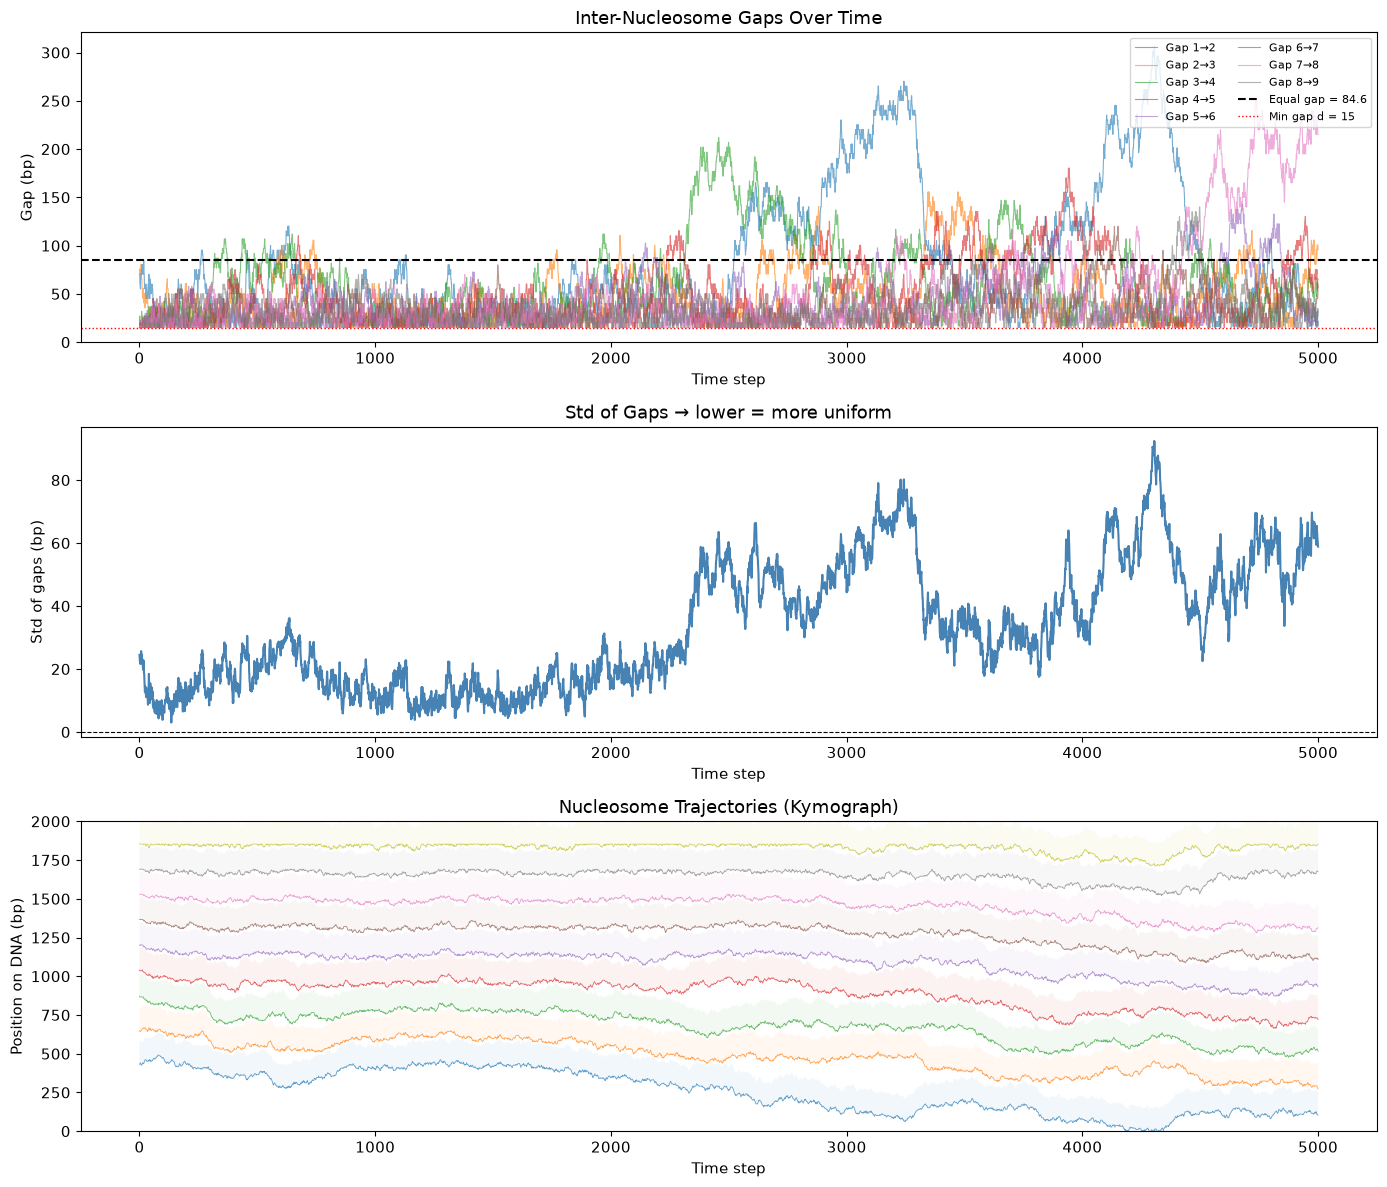

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
t = np.arange(len(history))

# ---------- Panel 1: 间距随时间变化 ----------
ax1 = axes[0]
for i in range(N - 1):
    ax1.plot(t, all_gaps[:, i], alpha=0.12, lw=0.7, color=f'C{i}')
    ax1.plot(t, smoothed_gaps[:, i], lw=1.6, color=f'C{i}', label=f'Gap {i+1}→{i+2}')
ax1.axhline(EQUAL_GAP, color='black', ls='--', lw=1.5, label=f'Equal gap = {EQUAL_GAP:.1f}')
ax1.axhline(d, color='red', ls=':', lw=1, label=f'Min gap d = {d}')
ax1.set_xlabel('Time step')
ax1.set_ylabel('Gap (bp)')
ax1.set_title(f'Inter-Nucleosome Gaps Over Time (smoothed, window={SMOOTH_WINDOW})')
ax1.legend(loc='upper right', fontsize=8, ncol=2)
ax1.set_ylim(bottom=0)

# ---------- Panel 2: 间距标准差（收敛指标）----------
ax2 = axes[1]
ax2.plot(t, gap_std, color='steelblue', lw=0.8, alpha=0.25, label='Raw std')
ax2.plot(t, smoothed_gap_std, color='steelblue', lw=2.0, label='Smoothed std')
ax2.axhline(0, color='black', ls='--', lw=0.8)
ax2.set_xlabel('Time step')
ax2.set_ylabel('Std of gaps (bp)')
ax2.set_title('Std of Gaps → lower = more uniform')
ax2.legend()

# ---------- Panel 3: Kymograph（轨迹图）----------
ax3 = axes[2]
plot_steps = min(len(history), 2000)
stride = max(1, len(history) // plot_steps)

for i in range(N):
    traj = history[::stride, i]
    t_axis = np.arange(0, len(history), stride)
    ax3.plot(t_axis, traj, lw=0.6, alpha=0.7)
    ax3.fill_between(t_axis, traj, traj + L_NUC, alpha=0.06)

ax3.set_xlabel('Time step')
ax3.set_ylabel('Position on DNA (bp)')
ax3.set_title('Nucleosome Trajectories (Kymograph)')
ax3.set_ylim(0, L)

plt.tight_layout()
plt.show()

## 5. 初始 vs 最终构型对比

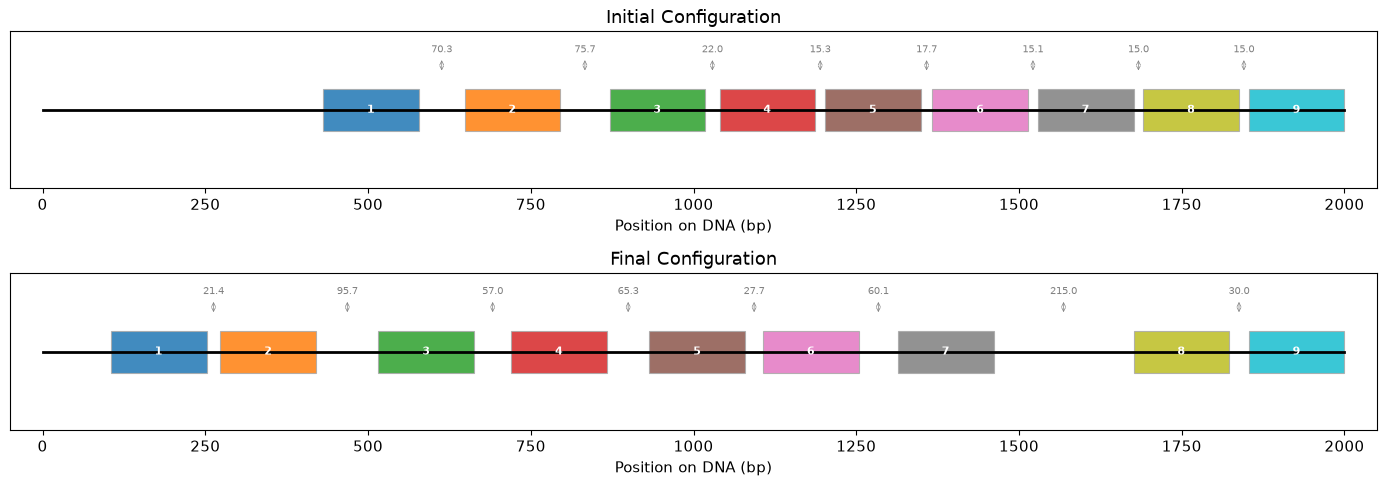

In [42]:
fig2, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(14, 5))

colors = plt.cm.tab10(np.linspace(0, 1, N))

for ax, h, title in [(ax_a, history[0], 'Initial'), (ax_b, history[-1], 'Final')]:
    ax.plot([0, L], [0, 0], 'k-', lw=2)  # DNA
    ax.set_xlim(-50, L + 50)
    ax.set_ylim(-1.5, 1.5)
    ax.set_yticks([])
    ax.set_xlabel('Position on DNA (bp)')
    ax.set_title(f'{title} Configuration')

    for i, (p, c) in enumerate(zip(h, colors)):
        rect = Rectangle((p, -0.4), L_NUC, 0.8,
                          facecolor=c, edgecolor='darkgray', lw=0.8, alpha=0.85)
        ax.add_patch(rect)
        ax.text(p + L_NUC / 2, 0, str(i + 1), ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')

    # 标注间距
    for i in range(N - 1):
        gap_start = h[i] + L_NUC
        gap_end = h[i + 1]
        gap_mid = (gap_start + gap_end) / 2
        ax.annotate(f'{gap_end - gap_start:.1f}',
                    xy=(gap_mid, 0.7), ha='center', fontsize=7, color='gray',
                    arrowprops=dict(arrowstyle='<->', color='gray', lw=0.5),
                    xytext=(gap_mid, 1.1))

plt.tight_layout()
plt.show()

## 6. 小结

- 新规则：每步三选一（左/停/右），停止的核小体会对邻居侵入做出反冲
- 从 Panel 1 看：各间距是否向 `EQUAL_GAP`（虚线）汇聚？
- 从 Panel 2 看：间距的标准差是否随时间下降？
- 从 Panel 3（Kymograph）看：核小体轨迹是否逐渐形成规则间距？
- 对比旧版（纯随机方向），三选一 + 反冲机制是否加速了有序化？